# 전처리 & 머신러닝 통합 개인과제

## Part 2. 구매 고객 특성 분석 및 시각화

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
이에 데이터 분석팀은 Part 1에서 정제한 고객 데이터를 활용하여 **구매율과 구매금액이 높은 고객군을 찾고, 고객의 구매 행동을 설명할 수 있는 주요 변수를 확인**하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 고객군별 구매 특성을 비교합니다.
2. 구매 행동의 분포와 변수 간 관계를 시각화합니다.
3. 분석 결과를 바탕으로 Part 3 구매예측 모델에 사용할 Feature 후보를 정리합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 분석을 위한 심화 문제이며 선택적으로 수행합니다.  
> 차트 종류와 표현 방식은 정해진 하나의 답만 있는 것이 아닙니다. 분석 목적에 적절하고 제목·축·범례가 명확하면 인정합니다.

## 과제 목표

- 전처리된 데이터의 주요 구매 현황을 확인할 수 있습니다.
- 두 개 이상의 기준으로 고객 데이터를 집계하고 집단별 구매 차이를 설명할 수 있습니다.
- 분석 목적에 적합한 차트를 선택하고 기본 시각 요소를 설정할 수 있습니다.
- EDA 결과를 근거로 머신러닝 Feature 후보를 제안할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 주요 고객군의 구매 특성 비교

## 업무 상황

CRM팀은 프로모션 대상을 정하기 위해 어떤 고객군의 구매율과 구매금액이 높은지 확인하려고 합니다.  
전체 평균만 확인하면 집단별 차이를 알기 어렵기 때문에, 고객 특성을 기준으로 구매 실적을 비교해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
3. 회원등급, 지역, 연령대, 선호 카테고리 중 적절한 기준을 선택하여 고객군별 구매 특성을 집계하세요.
4. **두 개 이상의 기준을 함께 사용한 그룹 집계**를 1개 이상 수행하세요.
5. 집계 결과를 바탕으로 구매율 또는 평균 구매금액이 높은 고객군을 간단히 설명하세요.

## 힌트

- 고객 수, 구매 고객 수, 구매율, 평균 구매금액, 평균 방문횟수 등을 집계 지표로 활용할 수 있습니다.
- 구매율이 높더라도 고객 수가 매우 적다면 해석에 주의해야 합니다.

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
%config InlineBackend.figure_format = 'retina'

DATA_PATH = Path("전자상거래_고객구매_전처리완료.csv")

# TODO: 전처리 완료 데이터를 불러와 df에 저장하세요.
df = pd.read_csv(DATA_PATH)

# TODO: 데이터 크기, 주요 컬럼과 앞부분을 확인하세요.

print("데이터 크기 :", df.shape)
print("컬럼 :", df.columns.to_list())
display(df.head())

데이터 크기 : (1465, 20)
컬럼 : ['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel', 'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount', 'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed', 'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus', 'AgeGroup', 'PurchaseGrade', 'RecenctPurchaseDays', 'SignedDays', 'AmountPerVisit']


,CustomerID,Gender,Age,Region,MembershipLevel,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore,LastPurchaseDate,CouponUsed,PreferredCategory,SignupDate,Email,PurchaseStatus,AgeGroup,PurchaseGrade,RecenctPurchaseDays,SignedDays,AmountPerVisit
0,CUST101486,F,40.0,Seoul,Silver,5,75000.0,139800.0,3.7,2026-02-07,N,Beauty,2022-12-03,customer1486@example.com,0,40,1,114,1276,27960
1,CUST100113,M,39.0,Gyeonggi,Basic,7,74400.0,159200.0,4.8,2026-04-22,N,Home,2021-07-16,customer113@example.com,1,30,1,40,1781,22742
2,CUST101212,M,44.0,Daegu,Vip,7,153900.0,413200.0,4.5,2026-05-07,N,Home,2021-10-27,customer1212@example.com,1,40,2,25,1678,59028
3,CUST100312,M,37.0,Gyeonggi,Basic,14,123700.0,576000.0,4.0,2026-04-16,N,Home,2025-11-08,customer312@example.com,1,30,3,46,205,41142
4,CUST100600,F,47.0,Daejeon,Vip,10,246700.0,1060200.0,2.6,2026-01-31,Y,Beauty,2025-01-28,customer600@example.com,1,40,3,121,489,106020


In [111]:
# TODO: 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.

print('전체 고객 수 :', df['CustomerID'].count())
print('구매 고객 수 :', df['PurchaseStatus'].sum())
print('구매율 :', ((df['PurchaseStatus'].sum() / df['CustomerID'].count()) * 100).round(2))

display(df.describe().round(2))

전체 고객 수 : 1465
구매 고객 수 : 711
구매율 : 48.53


,Age,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore,PurchaseStatus,AgeGroup,PurchaseGrade,RecenctPurchaseDays,SignedDays,AmountPerVisit
count,1465.00,1465.00,1465.00,1465.00,1465.00,1465.00,1465.00,1465.00,1465.00,1465.00,1465.00
mean,39.30,9.03,119584.98,386824.91,3.66,0.49,34.51,2.00,46.76,1165.29,42109.04
std,10.63,2.95,51443.33,259866.40,0.75,0.50,11.02,0.71,51.91,582.52,25184.95
min,18.00,1.00,5000.00,5000.00,1.10,0.00,10.00,1.00,-28.00,150.00,883.00
25%,32.00,7.00,83700.00,184200.00,3.20,0.00,30.00,2.00,8.00,664.00,23890.00
50%,39.00,9.00,117500.00,332800.00,3.70,0.00,30.00,2.00,37.00,1149.00,37740.00
75%,47.00,11.00,148900.00,534600.00,4.20,1.00,40.00,3.00,73.00,1685.00,55666.00
max,69.50,17.00,246700.00,1060200.00,5.00,1.00,60.00,3.00,315.00,2166.00,265050.00


In [112]:
# TODO: 고객 특성 한 가지를 기준으로 구매 특성을 집계하세요.
# 선호하는 품목 카테고리에 따른 평균 나이, 구매 고객 수, 평균 방문률

feature_group1 = df.groupby('PreferredCategory').agg(Age = ('Age', 'mean'),
                                                     Count = ('Gender', 'count'),
                                                     Visit_Count = ('VisitCount', 'mean')
                                                     ).round(2)

display(feature_group1.reset_index())

# TODO: 두 개 이상의 기준을 함께 사용하여 그룹 집계를 수행하세요.
# 선호하는 품목 카테고리와 성별에 따른 고객 수, 평균 총 구매금액, 평균 만족도

feature_group2 = df.groupby(['PreferredCategory', "Gender"]).agg(Count = ('Gender', 'count'),
                                                                 Total_Purchase_Amount = ('TotalPurchaseAmount', 'mean'),
                                                                 Satisfaction_Score = ('SatisfactionScore', 'mean')
                                                                 ).round(2)
display(feature_group2.reset_index())

,PreferredCategory,Age,Count,Visit_Count
0,Beauty,39.12,234,9.10
1,Electronics,39.34,257,9.04
2,Fashion,39.46,366,9.20
3,Food,39.30,242,8.79
4,Home,39.50,205,8.70
5,Sports,38.90,161,9.36


,PreferredCategory,Gender,Count,Total_Purchase_Amount,Satisfaction_Score
0,Beauty,F,139,422399.28,3.66
1,Beauty,M,95,408235.79,3.67
2,Electronics,F,133,502501.50,3.61
3,Electronics,M,124,508708.87,3.64
4,Fashion,F,180,358142.78,3.71
5,Fashion,M,186,360641.94,3.60
6,Food,F,139,353844.60,3.63
7,Food,M,103,320082.52,3.69
8,Home,F,112,353013.39,3.64
9,Home,M,93,312007.53,3.70


### 문제 1 결과 정리

- 전체 구매 현황: 현재 데이터에서 구매율은 48.53%
- 구매율이 높은 고객군: Vip (82%)
- 평균 구매금액이 높은 고객군: Vip (195,287.25원)
- 고객 수를 함께 고려했을 때 주의할 점:

    - 고객 수를 함께 고려했을 때, 구매율이 높더라도 해당 고객군의 고객 수가 적다면 전체 고객을 대표한다고 보기 어려우므로 해석에 주의해야 한다.

    - VIP 고객군은 구매율이 82%로 가장 높고 평균 구매금액도 약 195,287원으로 가장 높지만 고객 수는 102명으로 가장 적다. 
    
    - 반면, Basic 고객군은 구매율과 평균 구매금액은 낮지만 고객 수가 683명으로 가장 많기 때문에 전체 매출이나 고객 행동에 미치는 영향이 클 수 있다.


In [113]:
# 문제 
# 1-1) 구매율이 높은 고객군

display(
    df.groupby(["MembershipLevel"]).agg(고객수 = ("MembershipLevel", "count"),
                                        구매율 = ("PurchaseStatus", "mean")).reset_index().round(2).sort_values('구매율', ascending=False)
    )

# 1-2) 평균 구매금액이 높은 고객군
display(
    df.groupby(["MembershipLevel"]).agg(고객수 = ("MembershipLevel", "count"),
                                        평균구매금액 = ("AveragePurchaseAmount", "mean")).reset_index().round(2).sort_values('평균구매금액', ascending=False)
    )

,MembershipLevel,고객수,구매율
3,Vip,102,0.82
1,Gold,271,0.60
2,Silver,409,0.43
0,Basic,683,0.42


,MembershipLevel,고객수,평균구매금액
3,Vip,102,192463.73
1,Gold,271,149112.92
2,Silver,409,118312.22
0,Basic,683,97747.29


# 문제 2. 구매 행동의 분포와 관계 시각화

## 업무 상황

고객군별 평균만으로는 실제 데이터가 어느 구간에 집중되어 있는지, 일부 극단값이 평균에 영향을 주는지 알기 어렵습니다.  
CRM팀이 결과를 쉽게 이해할 수 있도록 구매 행동의 분포, 고객군 간 차이, 변수 간 관계를 시각화해야 합니다.

## 필수 요구사항

1. 구매금액, 방문횟수, 만족도 등 주요 수치형 변수 중 하나 이상의 분포를 시각화하세요.
2. 회원등급, 구매 여부 등 고객 집단별 차이를 비교할 수 있는 차트를 작성하세요.
3. 두 수치형 변수의 관계를 확인할 수 있는 차트를 작성하세요.
4. 모든 차트에 분석 내용을 이해할 수 있는 제목과 축 이름을 표시하고, 필요한 경우 범례를 추가하세요.
5. 차트에서 확인한 주요 패턴을 간단히 설명하세요.

## 힌트

- 분포 확인에는 히스토그램이나 박스플롯을 사용할 수 있습니다.
- 집단 비교에는 막대그래프나 그룹별 박스플롯을 사용할 수 있습니다.
- 수치형 변수 관계에는 산점도를 사용할 수 있습니다.

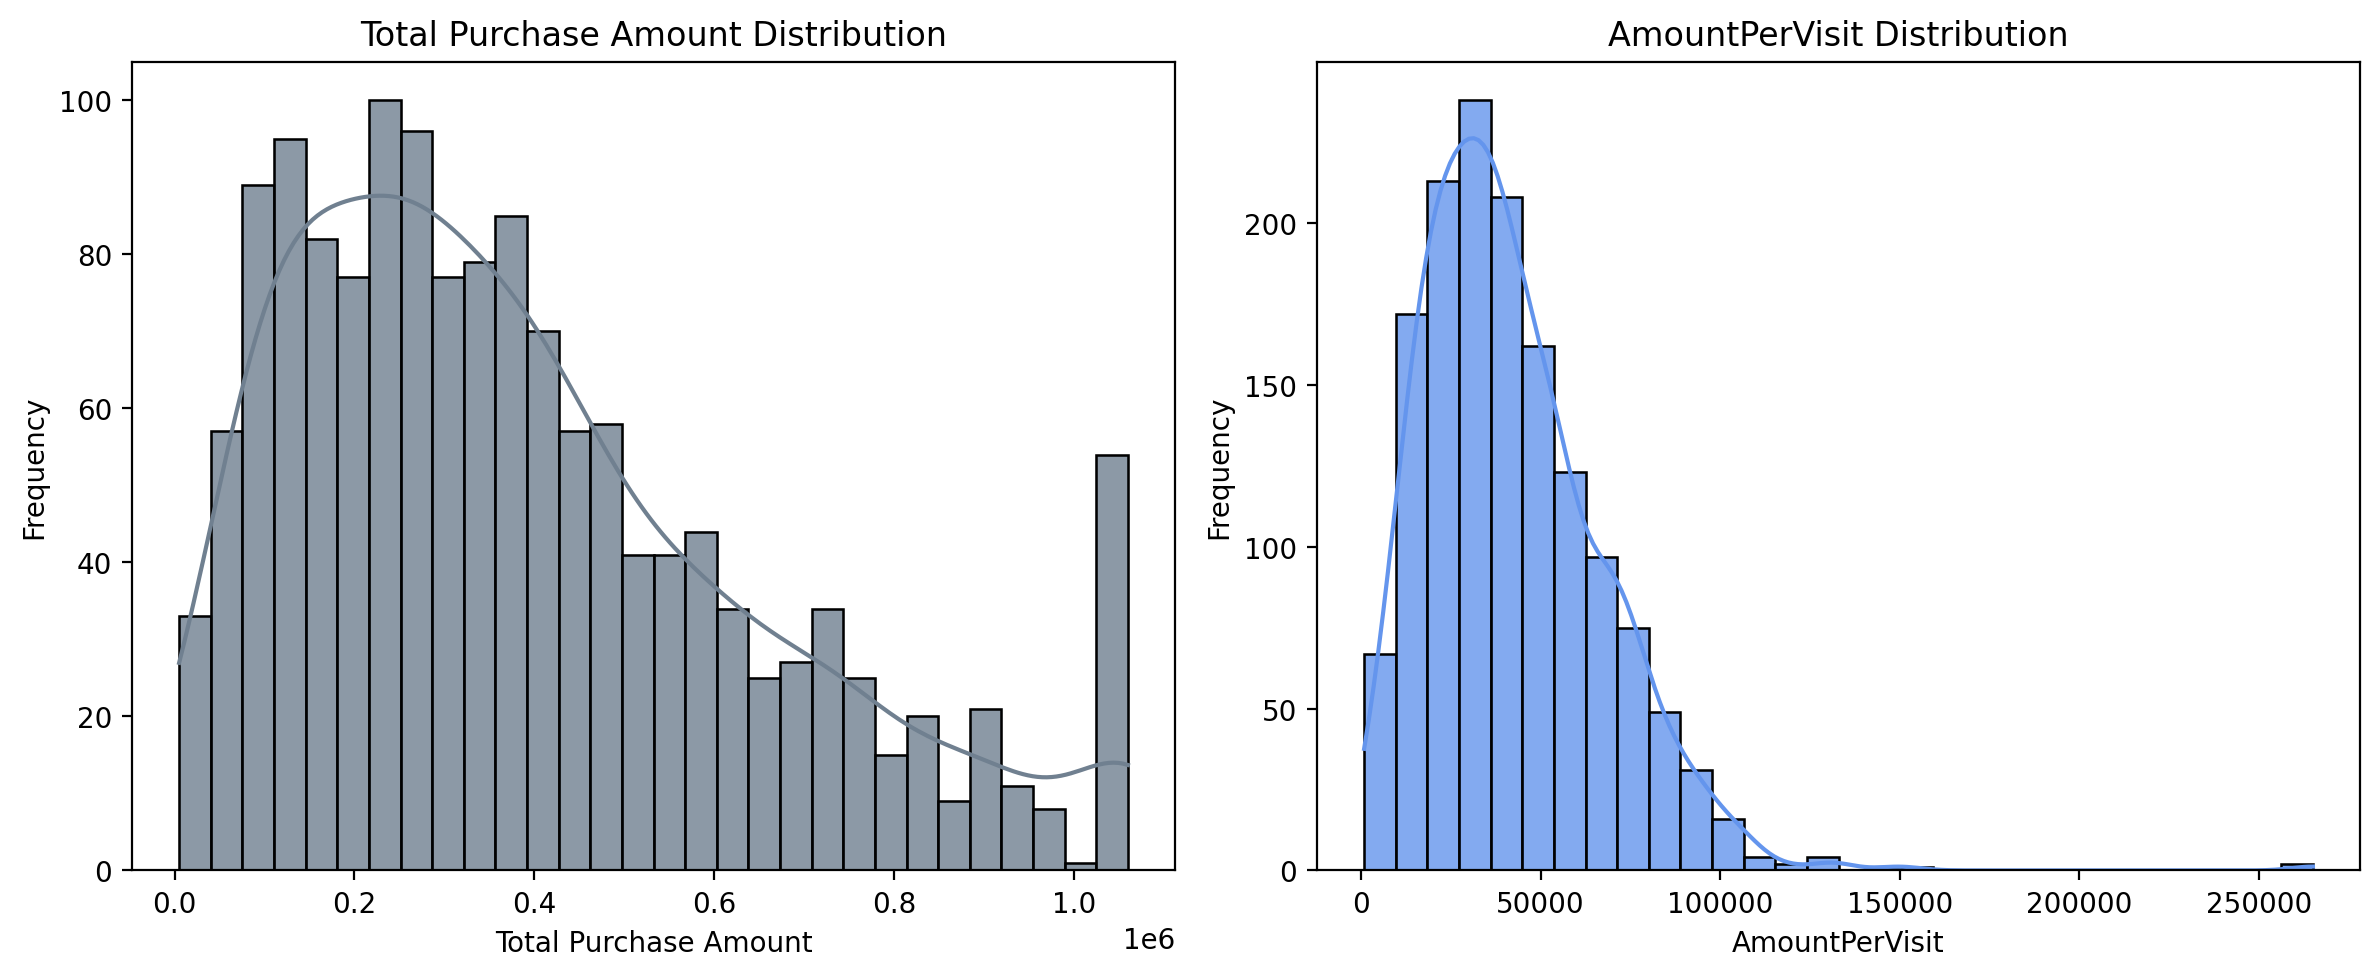

In [114]:
# TODO: 주요 수치형 변수의 분포를 시각화하세요.



fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# 1. 총 구매금액 분포 시각화

sns.histplot(data=df, x="TotalPurchaseAmount", bins=30, color= "slategray", alpha=0.8, edgecolor="black", kde=True, ax=ax[0])

ax[0].set_title("Total Purchase Amount Distribution")
ax[0].set_xlabel("Total Purchase Amount")
ax[0].set_ylabel("Frequency")



# 2. 방문당 구매 금액(AmountPerVisit) 시각화
sns.histplot(data=df, x="AmountPerVisit", bins=30, color= "cornflowerblue", alpha=0.8, edgecolor="black", kde=True, ax=ax[1])

ax[1].set_title("AmountPerVisit Distribution")
ax[1].set_xlabel("AmountPerVisit")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


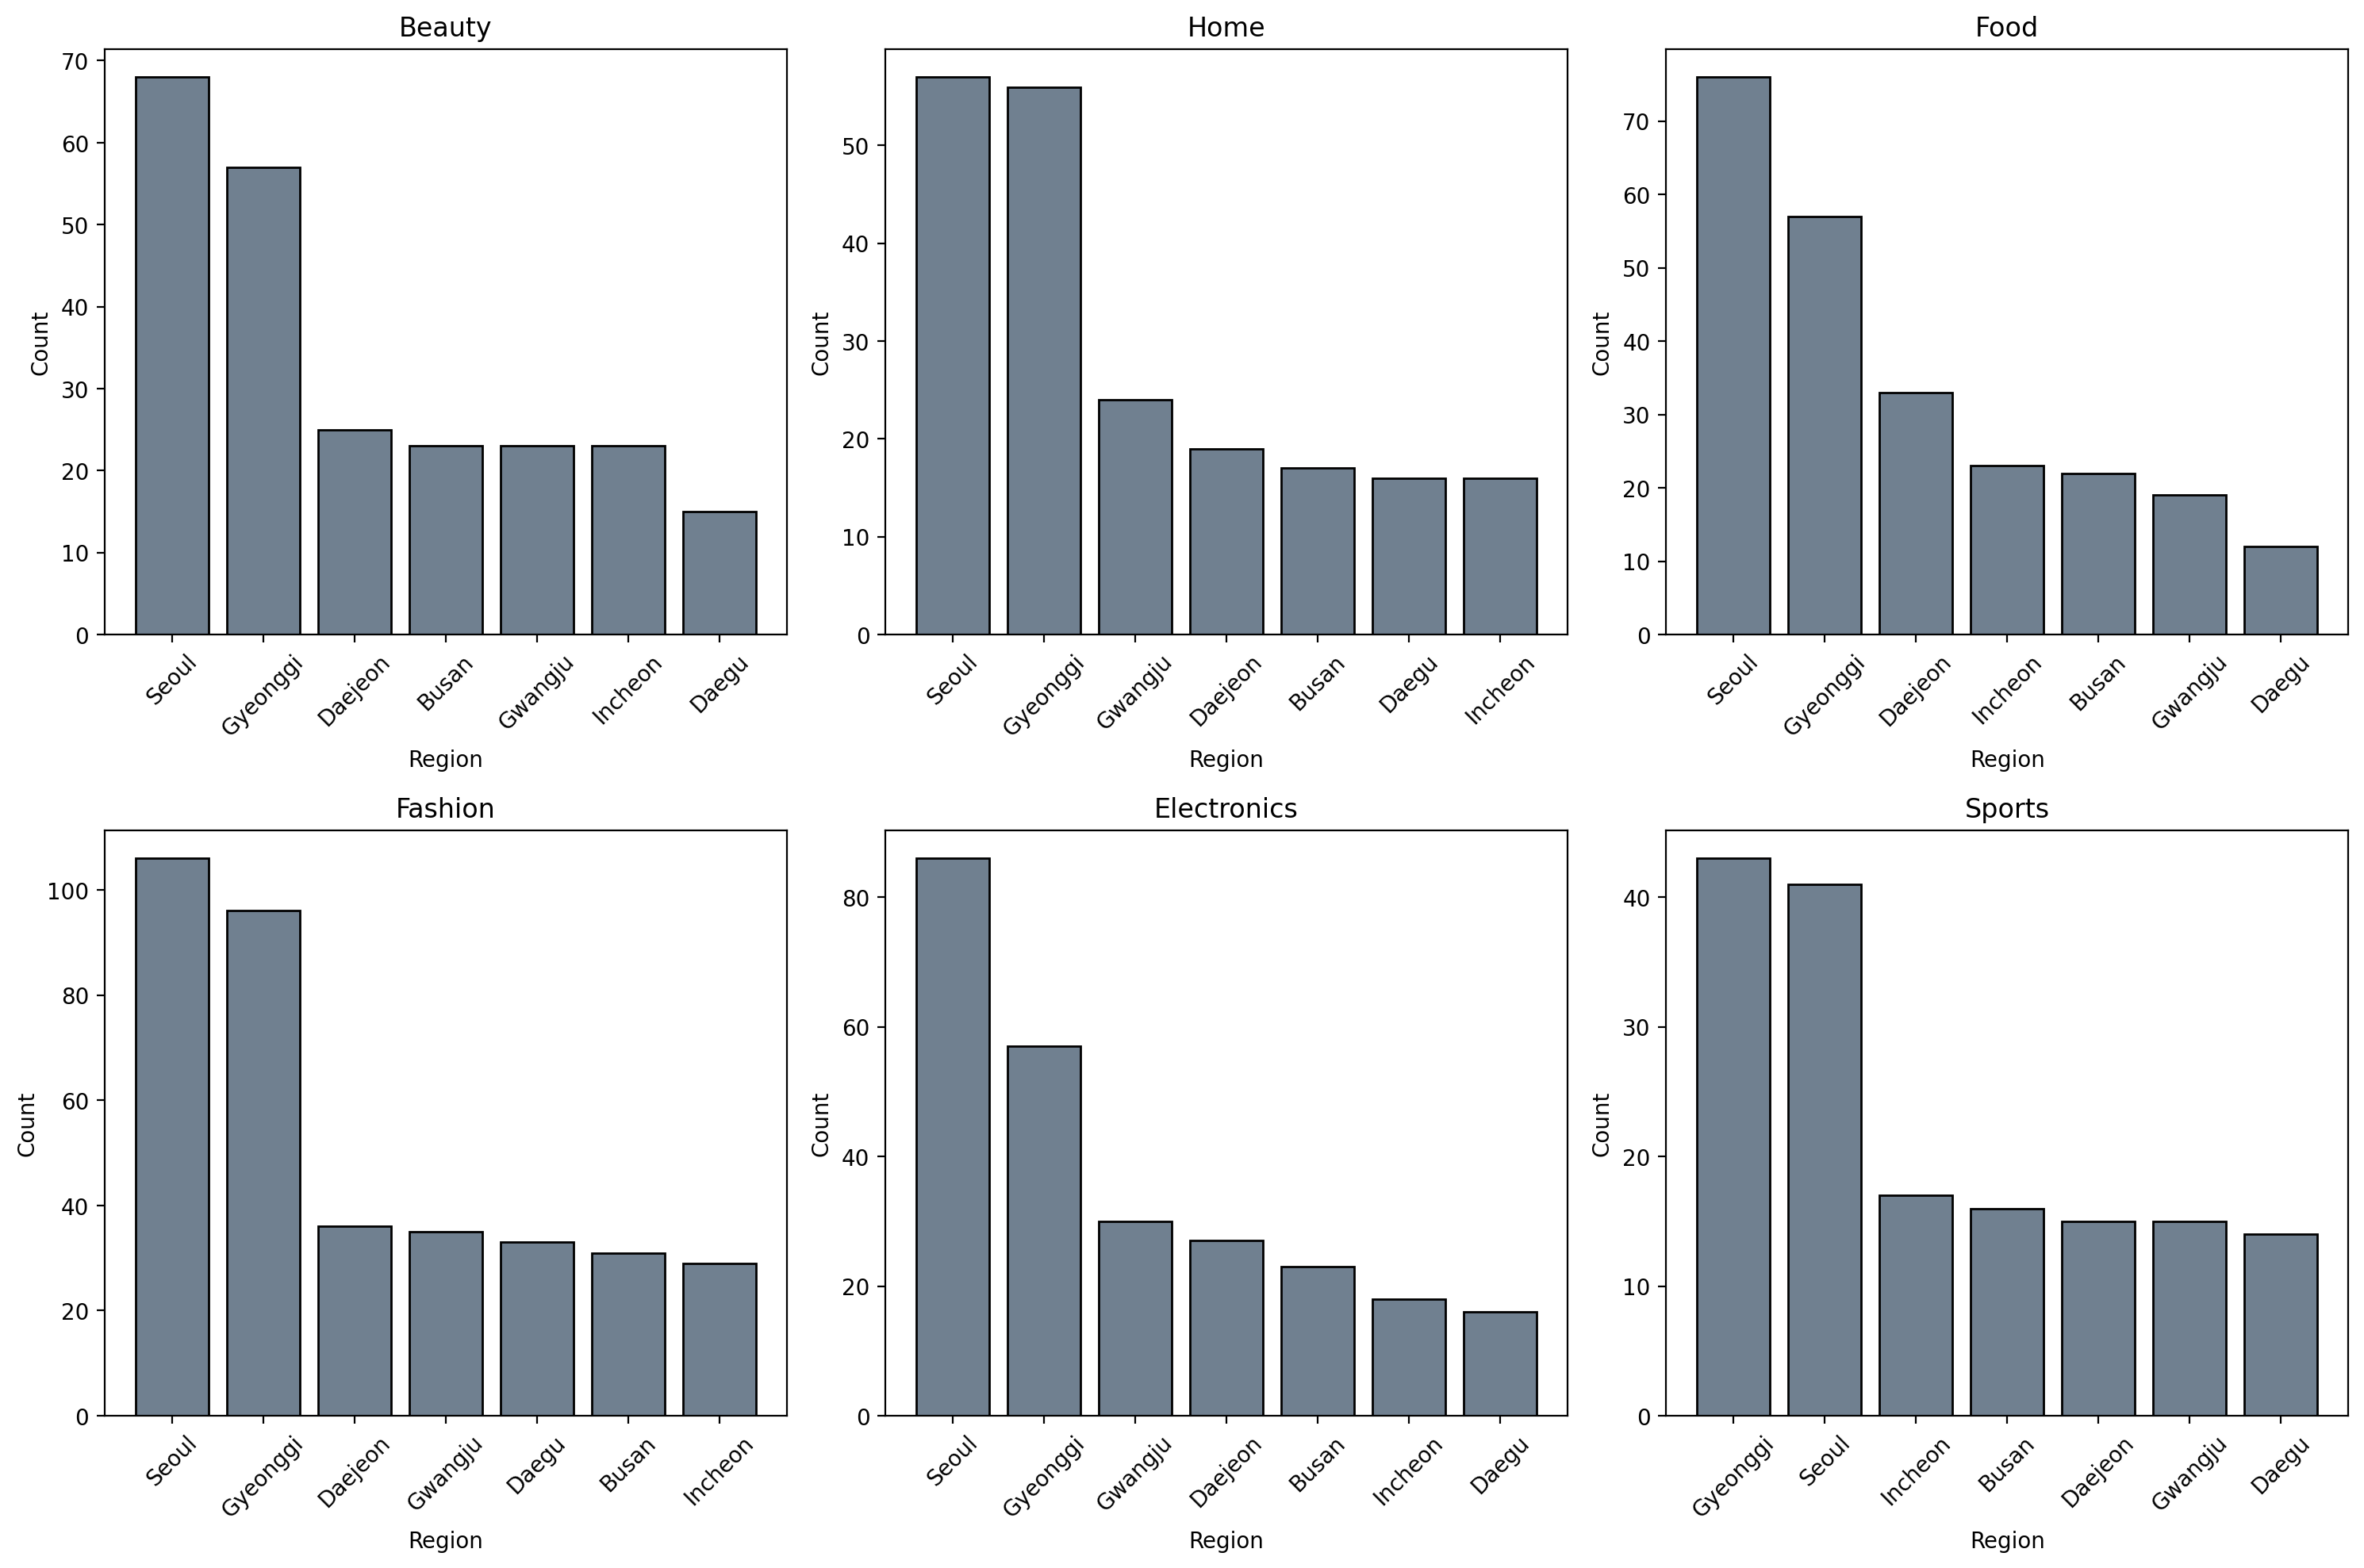

In [115]:
# TODO: 고객 집단별 구매 차이를 비교하는 차트를 작성하세요.

# 1. 선호 상품 카테고리에 따른 지역별 고객 수 차이

variable_cols = df['PreferredCategory'].unique()

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax = ax.flatten()

for i, category in enumerate(variable_cols):

    # 해당 카테고리 데이터
    data = df[df['PreferredCategory'] == category]

    # 지역별 고객 수 계산
    region_count = data['Region'].value_counts().sort_values(ascending=False)

    # 막대그래프
    ax[i].bar(
        region_count.index,    # x축: 지역
        region_count.values,   # y축: 개수
        color='slategray',
        edgecolor='black'
    )

    ax[i].set_title(category)
    ax[i].set_xlabel("Region")
    ax[i].set_ylabel("Count")
    ax[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

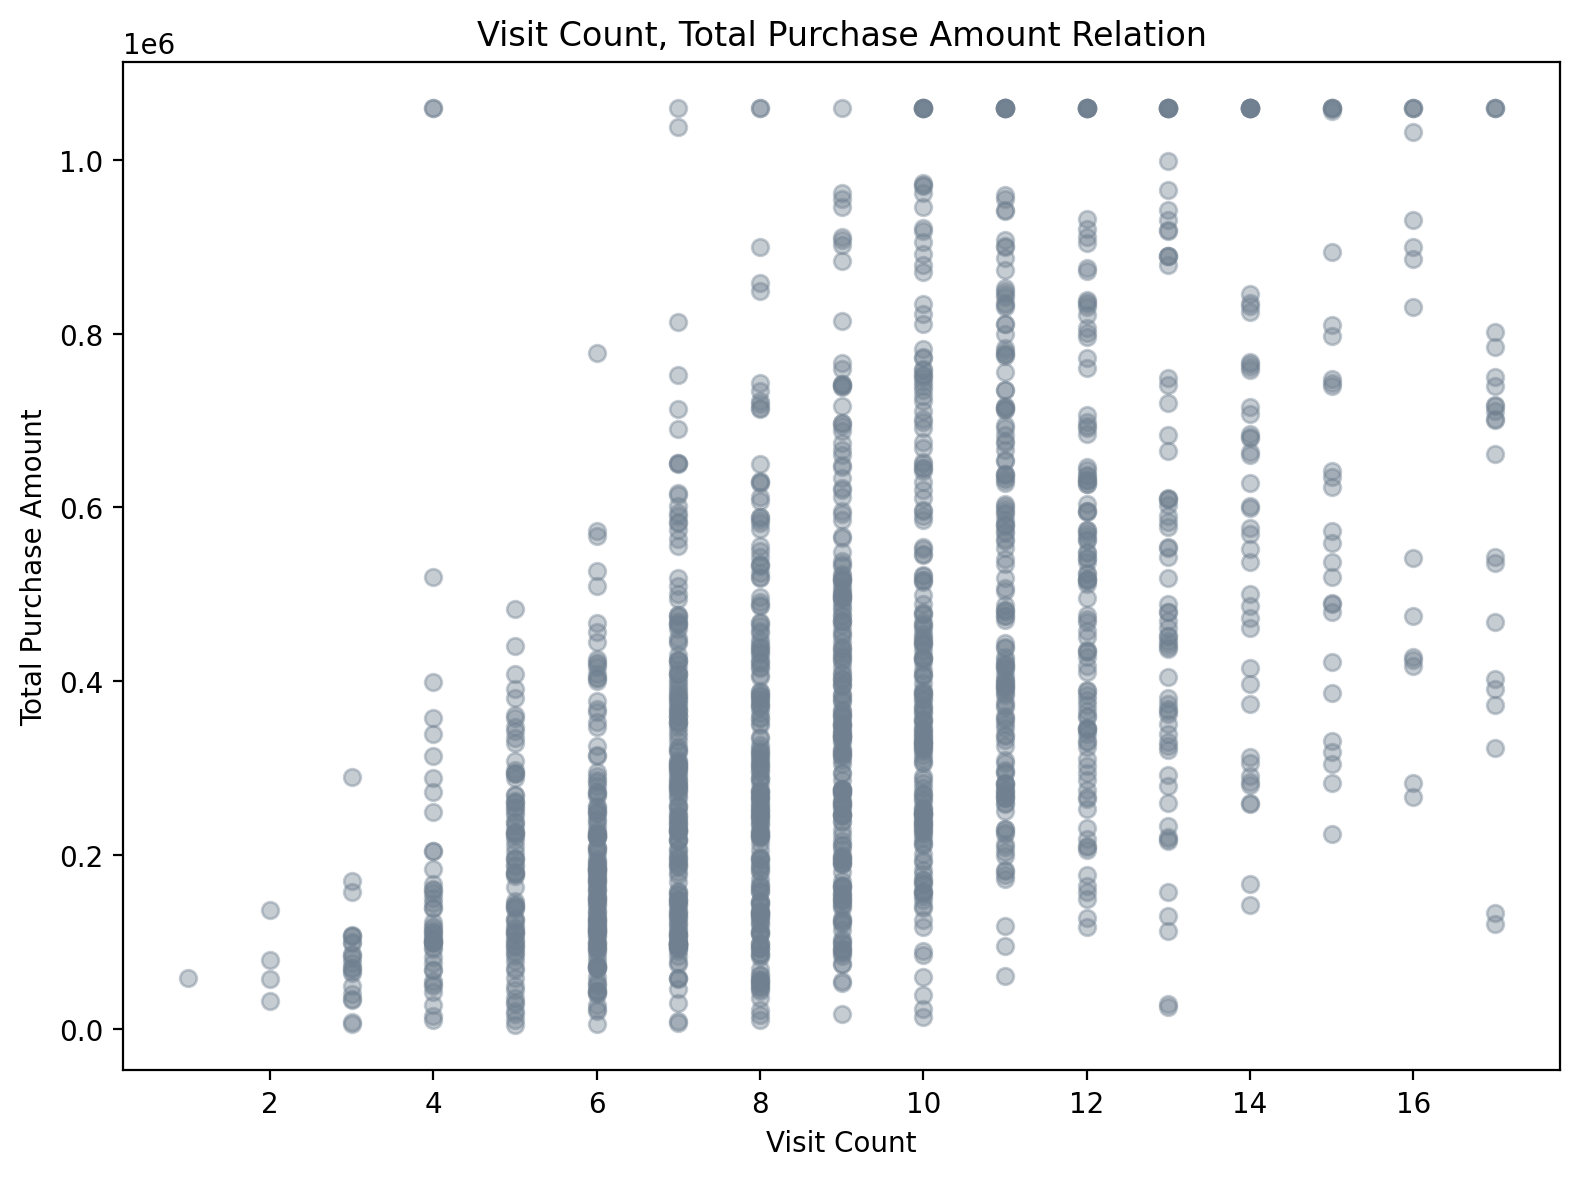

In [116]:
# TODO: 두 수치형 변수의 관계를 확인하는 차트를 작성하세요.

# VisitCount와 TotalPurchaseAmount의 관계
# -> 방문 횟수가 많을수록 총 구매금액이 높을까?


plt.figure(figsize=(8, 6))

plt.scatter(df['VisitCount'],df['TotalPurchaseAmount'],color='slategray', alpha=0.4)

plt.title("Visit Count, Total Purchase Amount Relation")
plt.xlabel("Visit Count")
plt.ylabel("Total Purchase Amount")

plt.tight_layout()
plt.show()

### 문제 2 결과 정리

- 주요 변수의 분포 특징:
    - `TotalPurchaseAmount`와 `AmountPerVisit`은 낮은 금액 구간에 고객이 많이 분포하며,
    - 높은 금액 방향으로 꼬리가 길게 나타나는 양의 왜도를 보인다.
    - 일부 높은 구매금액을 가진 고객이 존재하여 고객별 구매금액 차이가 큰 것으로 나타난다.

- 고객 집단별 차이:
    - 선호 상품 카테고리별 지역 고객 수를 비교한 결과,
      대부분의 카테고리에서 Seoul과 Gyeonggi 지역의 고객 수가 상대적으로 많았다.
    - 지역에 따라 선호 상품 카테고리의 고객은 차이가 있음이 나타난다.

- 두 수치형 변수 사이에서 확인한 관계:
    - `VisitCount`와 `TotalPurchaseAmount`는 양의 관계를 보인다.
    - 겹친 부분을 보아 방문 횟수가 많은 고객일수록 총 구매금액도 증가하는 경향이 나타났다.

- 시각화 결과가 고객 분석에 주는 의미:
    - 방문 횟수가 고객의 구매금액과 관련된 주요 행동 변수일 가능성이 있다.
    - 또한 지역별로 선호 상품의 고객 수가 다르기 때문에 지역과 상품 카테고리를 함께 고려하여 전략이 필요하다.

# 문제 3. 구매예측 모델링 Feature 후보 정리

## 업무 상황

Part 3에서는 고객의 구매 여부를 예측하는 머신러닝 모델을 개발합니다.  
모델에 모든 컬럼을 그대로 넣기보다, 이번 EDA에서 구매 행동과 관련성이 확인된 변수와 제외해야 할 변수를 구분해야 합니다.

## 필수 요구사항

1. 수치형 변수와 `PurchaseStatus`의 관계를 확인할 수 있는 표 또는 시각화를 작성하세요.
2. 문제 1과 문제 2의 분석 결과를 바탕으로 모델링에 사용할 Feature 후보를 정리하세요.
3. 고객 식별자처럼 일반적인 구매 패턴 학습에 적절하지 않은 컬럼을 제외 후보로 구분하세요.
4. 각 Feature 후보를 선정한 근거를 EDA 결과와 연결하여 간단히 설명하세요.

## 힌트

- 상관계수는 수치형 변수 사이의 선형 관계를 확인하는 참고 자료입니다.
- 상관계수가 낮더라도 범주형 변수나 비선형 관계를 가진 변수는 모델에 유용할 수 있습니다.
- 고객 ID와 같은 고유 식별자는 새로운 고객의 구매 패턴을 일반화하는 데 적절하지 않을 수 있습니다.

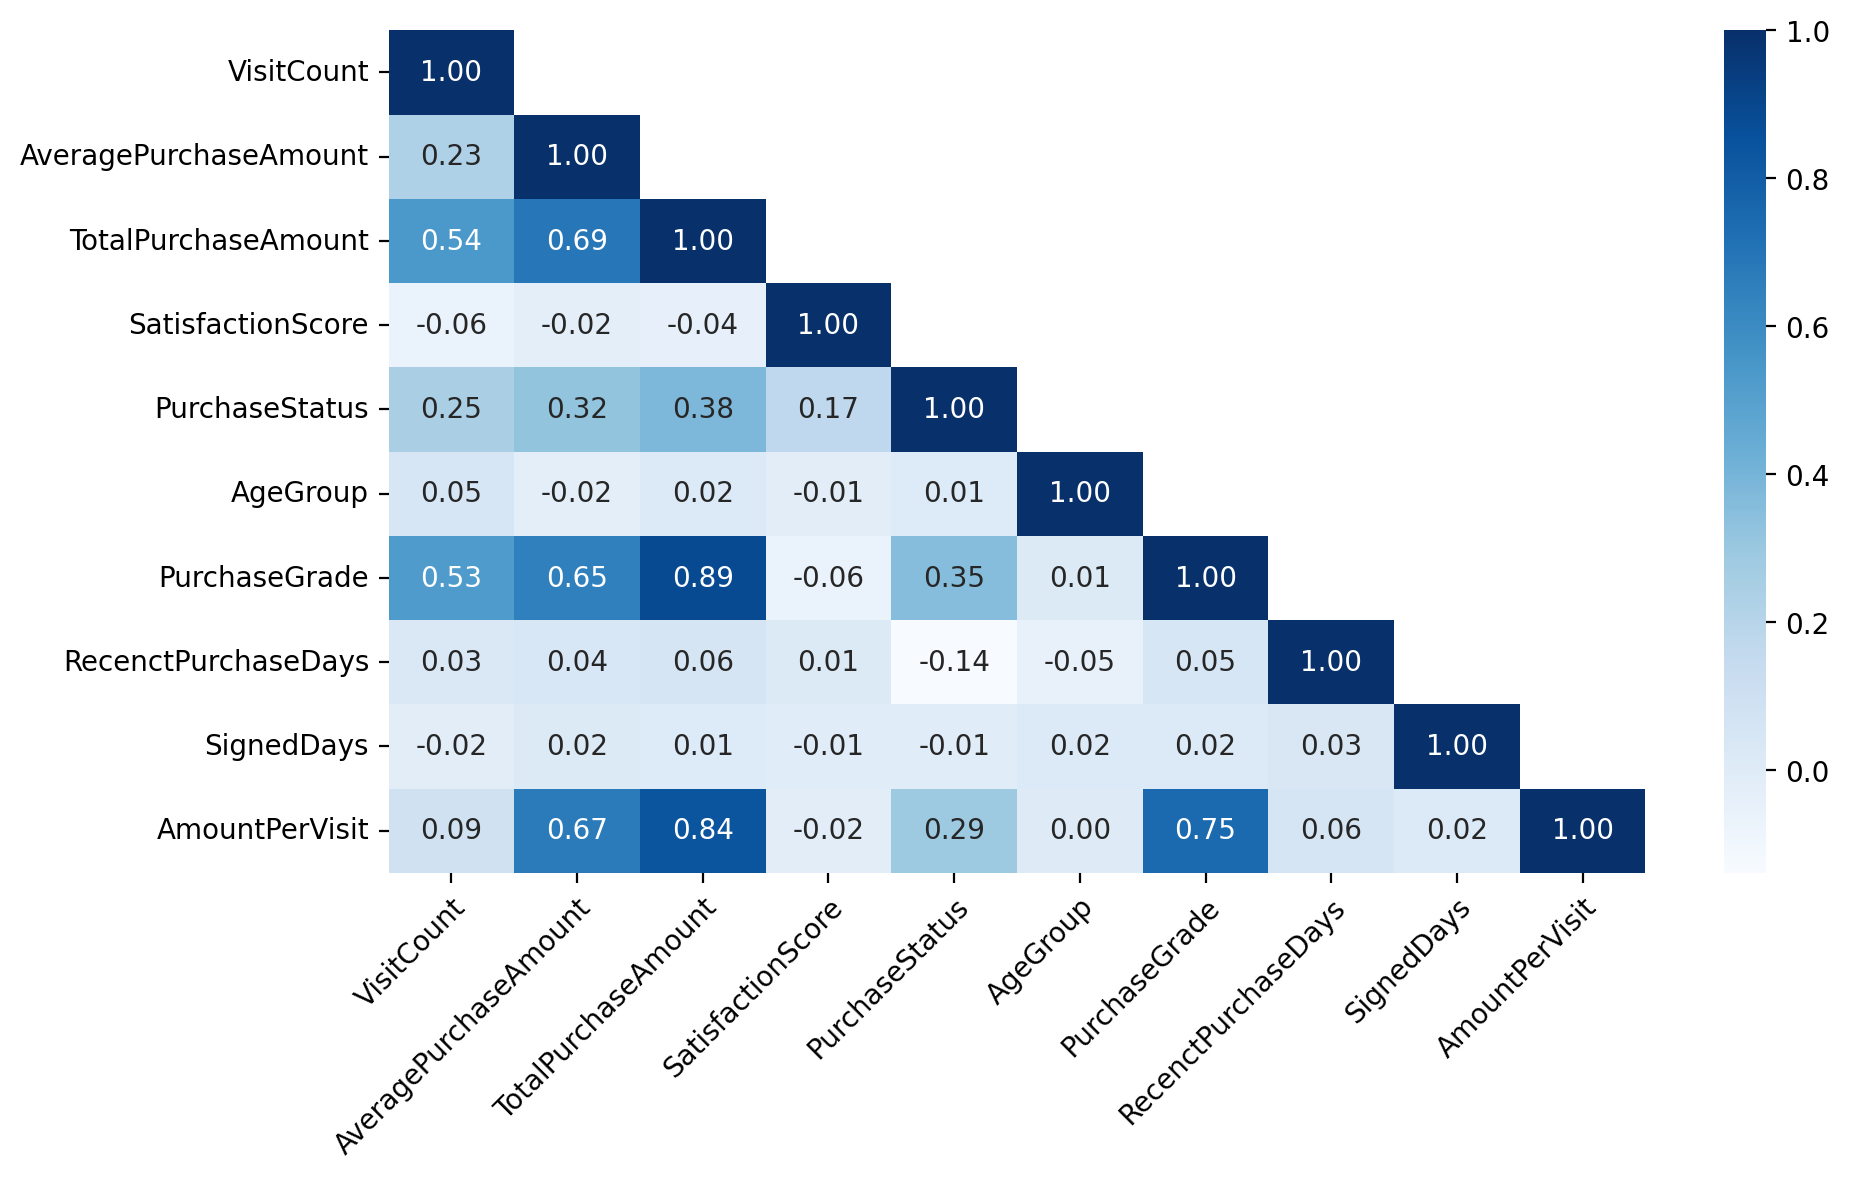

In [117]:
# TODO: 수치형 변수와 PurchaseStatus의 관계를 확인하세요.

num_cols = df.select_dtypes(include='number').columns.to_list()
num_cols.remove('Age')


plt.figure(figsize=(10, 6))

corr = df[num_cols].corr() # 수치형 변수 상관관계

mask = np.triu(np.ones_like(corr), k=1) # 반쪽 상관관계 mask

sns.heatmap(corr, annot=True, fmt='.2f', mask=mask, cmap="Blues")


plt.xticks(rotation=45,ha='right', rotation_mode='anchor')

plt.tight_layout()
plt.show()

In [119]:
# VIF (다중공선성) 지수 확인 (10이상은 변수간에 중복된 영향을 미친다고 판단)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 수치형 컬럼만 선택
X = df.select_dtypes(include='number').copy()
X = X.drop(columns=['Age', 'TotalPurchaseAmount'])

# 종속변수 제외
X = X.drop(columns='PurchaseStatus')

vif_list = []

for i in range(X.shape[1]):
    
    vif_value = variance_inflation_factor(X.values, i)
    
    vif_list.append({
        "Variable": X.columns[i],
        "VIF": vif_value,
        "Tolerance": 1 / vif_value
    })

vif_tol_df = pd.DataFrame(vif_list).round(2).sort_values("VIF",ascending=False)

vif_tol_df


# 파생변수인 'PurchaseGrade'는 'TotalPurchaseAmount'로부터 생성되어 다중공선성이 높은 것으로 판단. 따라서 'TotalPurchaseAmount' 변수 삭제 가능
# 파생변수인 `AmountPerVisit`은 방문 당 평균 구매 가격이므로 `TotalPurchaseAmount`와 `VisitCount`에서 파생된 변수

,Variable,VIF,Tolerance
4,PurchaseGrade,41.90,0.02
0,VisitCount,19.50,0.05
7,AmountPerVisit,13.94,0.07
1,AveragePurchaseAmount,12.67,0.08
2,SatisfactionScore,12.61,0.08
3,AgeGroup,8.93,0.11
6,SignedDays,4.66,0.21
5,RecenctPurchaseDays,1.81,0.55


In [122]:
# TODO: EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리하세요.

# 수치형 Feature 후보

numeric_features = [
    'VisitCount',
    'AveragePurchaseAmount',
    'SatisfactionScore',
    'RecenctPurchaseDays',
    'SignedDays',
    'AmountPerVisit'
]

# 범주형 Feature 후보
categorical_features = [
    'Gender',
    'Region',
    'MembershipLevel',
    'CouponUsed',
    'PreferredCategory',
    'AgeGroup',
    'PurchaseGrade'
]

# 제외 후보
exclude_features = [
    'CustomerID',
    'Email',
    'Age',
    'LastPurchaseDate',
    'SignupDate',
    'PurchaseStatus',
    'TotalPurchaseAmount'
]

print("수치형 Feature :\n", numeric_features)
print()
print("범주형 Feature :\n", categorical_features)
print()
print("제외 후보 :\n", exclude_features)

수치형 Feature :
 ['VisitCount', 'AveragePurchaseAmount', 'SatisfactionScore', 'RecenctPurchaseDays', 'SignedDays', 'AmountPerVisit']

범주형 Feature :
 ['Gender', 'Region', 'MembershipLevel', 'CouponUsed', 'PreferredCategory', 'AgeGroup', 'PurchaseGrade']

제외 후보 :
 ['CustomerID', 'Email', 'Age', 'LastPurchaseDate', 'SignupDate', 'PurchaseStatus', 'TotalPurchaseAmount']


### 문제 3 결과 정리

#### 모델링 Feature 후보

- 수치형 Feature:
    - VisitCount
    - AveragePurchaseAmount
    - SatisfactionScore
    - RecenctPurchaseDays
    - SignedDays
    - AmountPerVisit

- 범주형 Feature:
    - Gender
    - Region
    - MembershipLevel
    - CouponUsed
    - PreferredCategory
    - AgeGroup
    - PurchaseGrade

- 선정 근거:
    - `VisitCount`, `AveragePurchaseAmount`, `AmountPerVisit` : 고객의 행동을 나타내는 변수로 구매 여부를 설명하는 데 활용할 수 있다고 판단하였다.
    - `SatisfactionScore` : 고객의 서비스 만족도를 나타내므로 구매 행동과의 관계를 확인하기 위한 변수로 선정하였다.
    - `RecenctPurchaseDays` : 최근 구매 이후 경과일을 나타내어 고객의 최근 구매 활동을 반영할 수 있다.
    - `SignedDays` : 가입 이후 경과 기간을 나타내므로 고객의 이용 기간과 구매 행동의 관계를 확인할 수 있다.
    - `Gender`, `Region`, `MembershipLevel`, `CouponUsed`, `PreferredCategory` : 고객의 특성과 구매 집단을 구분할 수 있는 범주형 변수이므로 Feature 후보로 선정하였다.
    - `AgeGroup` : 연령을 구간화하여 고객의 연령대별 구매 특성을 비교할 수 있어 원본 Age 대신 사용하였다.
    - `PurchaseGrade` : 고객의 구매 수준을 구분하는 범주형 변수로 고객 집단별 구매 특성을 설명하는 데 활용할 수 있다고 판단하였다.

#### 제외 후보

- 제외할 컬럼:
    - CustomerID
    - Email
    - Age
    - LastPurchaseDate
    - SignupDate
    - PurchaseStatus
    - TotalPurchaseAmount

- 제외 이유:
    - `CustomerID`, `Email` : 고객을 식별하기 위한 고유 정보이므로 고객의 구매 패턴을 설명하는 Feature로 사용하기 어려워 제외한다.
    - `Age` : AgeGroup의 파생변수이며, 다중공선성을 줄이기 위해 제외한다.
    - `LastPurchaseDate` : RecenctPurchaseDays의 파생변수이므로 변수로 제외한다.
    - `SignupDate` : SignedDays의 파생변수이므로 제외하였다.
    - `PurchaseStatus` : 구매 여부를 나타내는 종속변수이므로 독립변수로 사용하지 않는다.
    - `TotalPurchaseAmount` : AveragePurchaseAmount, AmountPerVisit, PurchaseGrade 등 구매 관련 변수와 높은 관련성을 보이며 VIF와 가장 관련성이 높게 나타난 것으로 보아 변수에서 제거하여 변수 간의 중복 의미를 줄인다.


# (심화)문제 4. 분석 결과의 심화 해석

## 업무 상황

CRM팀은 기본 분석 결과를 실제 마케팅과 구매예측 모델에 적용하기 전에,
고객군별 결과의 활용 가능성과 해석상의 주의점, 모델링 변수 구성의 위험 요소를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 고객군 활용 방안 제안

1. 문제 1의 집계 결과를 바탕으로 우선 관리할 고객군을 한 개 이상 선정하세요.
2. 해당 고객군을 선정한 근거를 구매율, 평균 구매금액, 고객 수 등의 지표와 연결하여 작성하세요.
3. 선정한 고객군에 적용할 수 있는 마케팅 활용 방안을 한 가지 이상 제안하세요.

### 4-2. 시각화 결과 해석 시 주의점

1. 문제 2의 분포 또는 집단 비교 차트에서 확인되는 치우침, 극단값, 집단별 차이 중 하나 이상을 설명하세요.
2. 해당 결과를 해석할 때 주의해야 할 점을 작성하세요.
3. 필요하다면 기존 분석을 보완하는 추가 차트를 한 개 작성하세요.

### 4-3. 모델링 Feature 위험 요소 검토

1. 서로 비슷한 정보를 제공하여 중복 가능성이 있는 변수를 한 쌍 이상 제시하세요.
2. 예측 시점에 사용할 수 없거나 구매 결과를 직접 반영하여 데이터 누수 가능성이 있는 변수를 검토하세요.
3. 최종 Feature 구성을 수치형 변수와 범주형 변수로 나누어 정리하세요.



## 심화 문제 결과 작성

### 4-1. 고객군 활용 방안

- 우선 관리할 고객군:
- 선정 근거:
- 제안할 마케팅 활용 방안:

### 4-2. 시각화 해석 시 주의점

- 확인한 분포 또는 집단 차이:
- 해석 시 주의할 점:
- 추가로 작성한 차트와 확인 결과:

### 4-3. Feature 위험 요소

- 중복 정보 가능성이 있는 변수:
- 데이터 누수 가능성이 있는 변수:
- 최종 수치형 Feature:
- 최종 범주형 Feature:



# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 전체 구매 현황 | 전체 고객 수, 구매 고객 수, 구매율, 주요 기초 통계량 |
| 고객군별 집계표 | 단일 기준 및 두 개 이상 기준의 그룹 집계 |
| 고객군 해석 | 구매율 또는 평균 구매금액이 높은 고객군 설명 |
| 주요 시각화 | 분포, 고객 집단 비교, 두 수치형 변수 관계 차트 |
| Feature 후보 | 모델링에 사용할 Feature와 제외 후보 및 선정 근거 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 고객군 활용 방안 | 우선 관리 고객군과 마케팅 제안 |
| 시각화 해석 주의점 | 치우침·극단값·집단 차이 해석과 주의사항 |
| Feature 위험 검토 | 중복 정보와 데이터 누수 가능성 검토 |
| 최종 Feature 구성 | 수치형·범주형 Feature 구분 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] Part 1 전처리 완료 데이터를 사용했습니다.
- [ ] 전체 구매 현황과 주요 기초 통계량을 확인했습니다.
- [ ] 두 개 이상의 기준을 사용한 그룹 집계를 수행했습니다.
- [ ] 구매 특성이 두드러진 고객군을 설명했습니다.
- [ ] 분포, 집단 비교, 변수 관계를 확인할 수 있는 시각화를 작성했습니다.
- [ ] 차트에 제목, 축 이름과 필요한 범례를 표시했습니다.
- [ ] EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리했습니다.

## 심화 체크리스트

- [ ] 우선 관리할 고객군과 마케팅 활용 방안을 제안했습니다.
- [ ] 분포 또는 집단 차이를 해석할 때의 주의점을 설명했습니다.
- [ ] 필요에 따라 추가 차트를 작성했습니다.
- [ ] 중복 정보 가능성이 있는 변수를 검토했습니다.
- [ ] 데이터 누수 가능성이 있는 변수를 검토했습니다.
- [ ] 최종 Feature를 수치형과 범주형으로 구분했습니다.
